<!-- launch-badges -->
<a href="https://colab.research.google.com/github/laban254/ml-for-infrastructure/blob/main/03_machine_learning/scikit-learn/supervised-learning-algorithms/classification.ipynb" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
&nbsp;
<a href="https://mybinder.org/v2/gh/laban254/ml-for-infrastructure/main?urlpath=lab/tree/03_machine_learning/scikit-learn/supervised-learning-algorithms/classification.ipynb" target="_blank"><img src="https://mybinder.org/badge_logo.svg" alt="Open in Binder"/></a>

> ▶️ **Run this notebook live** — no install needed. Click a badge above to open it in a free cloud runtime.

# Predicting Server Health State with Classification

## Context
As an SRE, you want to automatically categorize the health state of your infrastructure (e.g., *Healthy*, *Warning*, *Critical*) rather than relying purely on static, single-metric thresholds. By feeding historical telemetry data and their known incident states into a classification model, you can predict when a server is entering a problematic state before it fails entirely.

## Objectives
- Generate synthetic operational telemetry data mapped to server health states.
- Train classification models: Logistic Regression, Random Forest Classifier, and Support Vector Classifier (SVC).
- Evaluate model accuracy and analyze the classification report (Precision, Recall, F1-Score).
- Understand feature importance to see which metrics drive state changes.

## Expected Outcome
- The ability to train and compare multiple classification algorithms on infrastructure telemetry, judging them by precision/recall per class and confusion matrices rather than raw accuracy alone.
- Insight into which telemetry signals most strongly predict a "Critical" server state, and how to read that signal out of a trained Random Forest.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

plt.style.use('ggplot')

### 1. Generating Synthetic Telemetry Data
We will generate data representing 1,500 server snapshots. We'll label them as 0 (Healthy), 1 (Warning), or 2 (Critical) based on underlying rules.

In [2]:
np.random.seed(42)
n_samples = 1500

# Telemetry features
cpu_usage = np.random.uniform(10, 100, n_samples)
memory_usage = np.random.uniform(20, 100, n_samples)
disk_io = np.random.normal(500, 200, n_samples)
network_latency = np.random.gamma(2, 10, n_samples)
error_rate = np.random.exponential(1.5, n_samples)

def determine_state(cpu, mem, error, latency):
    # Combinations of high metrics lead to worse states
    if error > 5 or (cpu > 90 and mem > 90):
        return 2  # Critical
    elif error > 2 or cpu > 75 or mem > 80 or latency > 40:
        return 1  # Warning
    else:
        return 0  # Healthy

# Apply logic to map features to a target state
states = [determine_state(cpu_usage[i], memory_usage[i], error_rate[i], network_latency[i]) for i in range(n_samples)]

df = pd.DataFrame({
    'cpu_usage': cpu_usage,
    'memory_usage': memory_usage,
    'disk_io': disk_io,
    'network_latency': network_latency,
    'error_rate': error_rate,
    'state': states
})

# Let's map integer states to string labels for clarity later
state_map = {0: 'Healthy', 1: 'Warning', 2: 'Critical'}
df['state_label'] = df['state'].map(state_map)

df.head()

,cpu_usage,memory_usage,disk_io,network_latency,error_rate,state,state_label
0,43.708611,61.526543,711.987277,10.769439,2.306177,1,Warning
1,95.564288,58.334550,623.401190,23.886553,2.585403,1,Warning
2,75.879455,22.051365,636.713865,39.622617,1.212800,1,Warning
3,63.879264,47.299826,226.808858,6.069972,0.297307,0,Healthy
4,24.041678,50.415650,742.388797,12.379312,0.945986,0,Healthy


### 2. Exploratory Data Analysis
How does error rate distinguish between states?

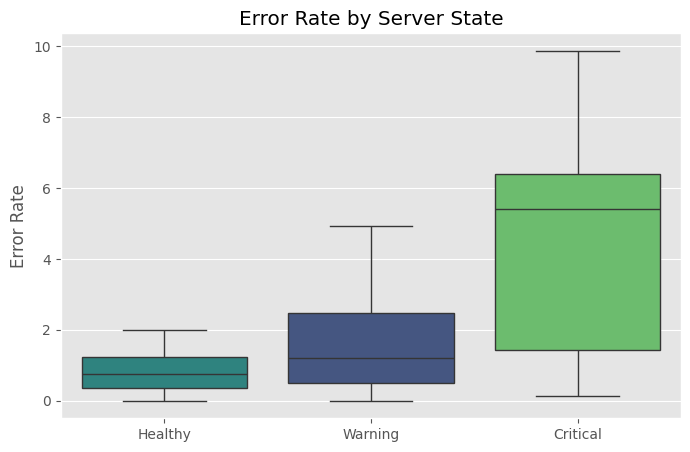

In [3]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='state_label', y='error_rate', data=df, order=['Healthy', 'Warning', 'Critical'], hue='state_label', palette='viridis', legend=False)
plt.title('Error Rate by Server State')
plt.ylabel('Error Rate')
plt.xlabel('')
plt.show()

### 3. Data Preparation (Scaling and Splitting)
Machine learning models often require features to be on the same scale (e.g., Disk I/O is in the hundreds, Memory is 0-100). We use `StandardScaler` to normalize the data.

In [4]:
X = df[['cpu_usage', 'memory_usage', 'disk_io', 'network_latency', 'error_rate']]
y = df['state']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 4. Training Classification Models

#### **Model A: Logistic Regression**
A foundational algorithm for classification. It works well if the boundary between states is relatively linear.

In [5]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
y_pred_log_reg = log_reg.predict(X_test_scaled)

print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_log_reg):.4f}\n")
print(classification_report(y_test, y_pred_log_reg, target_names=['Healthy', 'Warning', 'Critical']))

Logistic Regression Accuracy: 0.7800

              precision    recall  f1-score   support

     Healthy       0.75      0.75      0.75       114
     Warning       0.80      0.83      0.81       174
    Critical       0.83      0.42      0.56        12

    accuracy                           0.78       300
   macro avg       0.79      0.66      0.70       300
weighted avg       0.78      0.78      0.78       300



#### **Model B: Random Forest Classifier**
An ensemble model that builds multiple decision trees. Highly effective and handles complex, non-linear relationships well (like our "IF cpu > 90 AND mem > 90" rule).

In [6]:
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train_scaled, y_train)
y_pred_rf = rf_clf.predict(X_test_scaled)

print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}\n")
print(classification_report(y_test, y_pred_rf, target_names=['Healthy', 'Warning', 'Critical']))

Random Forest Accuracy: 1.0000

              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00       114
     Warning       1.00      1.00      1.00       174
    Critical       1.00      1.00      1.00        12

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



#### **Model C: Support Vector Classifier (SVC)**
Finds the optimal hyperplane that separates the classes. Excellent for high-dimensional spaces.

In [7]:
svc_clf = SVC(kernel='rbf', random_state=42)
svc_clf.fit(X_train_scaled, y_train)
y_pred_svc = svc_clf.predict(X_test_scaled)

print(f"SVC Accuracy: {accuracy_score(y_test, y_pred_svc):.4f}\n")
print(classification_report(y_test, y_pred_svc, target_names=['Healthy', 'Warning', 'Critical']))

SVC Accuracy: 0.9200

              precision    recall  f1-score   support

     Healthy       0.93      0.93      0.93       114
     Warning       0.92      0.95      0.93       174
    Critical       0.83      0.42      0.56        12

    accuracy                           0.92       300
   macro avg       0.89      0.76      0.81       300
weighted avg       0.92      0.92      0.92       300



### 5. Evaluation: Confusion Matrix
The Random Forest model above reached 100% accuracy in this run — with clean, well-separated synthetic labels, it produced a perfect diagonal and there's nothing left to diagnose. Let's instead look at the SVC confusion matrix, which does have real off-diagonal errors, to see specifically *where* that model makes mistakes. Are we predicting "Healthy" or "Warning" when a server is actually "Critical"? That would be a dangerous false negative.

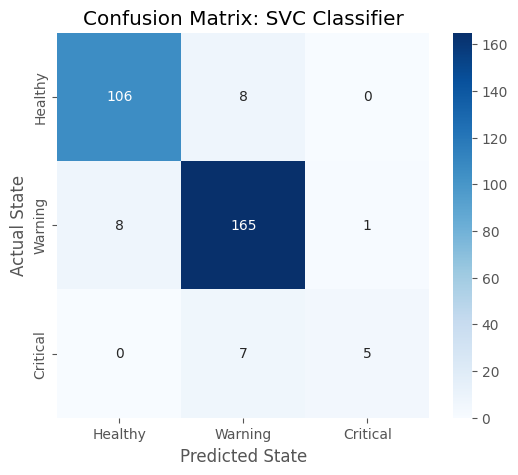

In [8]:
cm = confusion_matrix(y_test, y_pred_svc)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Healthy', 'Warning', 'Critical'],
            yticklabels=['Healthy', 'Warning', 'Critical'])
plt.xlabel('Predicted State')
plt.ylabel('Actual State')
plt.title('Confusion Matrix: SVC Classifier')
plt.show()

### 6. Feature Importance
Random Forest models give us the ability to see which features contributed most to the predictions. This tells us which telemetry metrics are the strongest leading indicators of server failure.

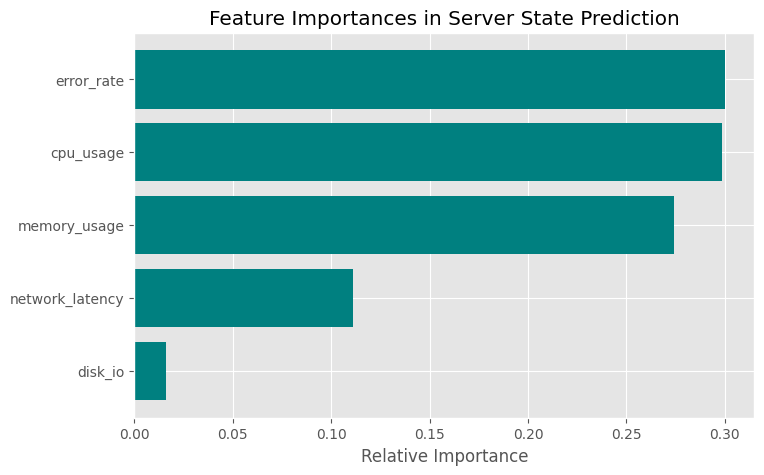

In [9]:
importances = rf_clf.feature_importances_
features = X.columns

indices = np.argsort(importances)

plt.figure(figsize=(8, 5))
plt.barh(range(len(indices)), importances[indices], color='teal', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.title('Feature Importances in Server State Prediction')
plt.xlabel('Relative Importance')
plt.show()

---
## 📝 Exercise: which signal predicts a 'Critical' server?

You trained a `RandomForestClassifier`. Pull out its `feature_importances_` and rank the five telemetry features. If you could only watch **one** metric on a dashboard, which would it be — and does that match your intuition as an operator?

```python
# your code here
# hint: zip(X.columns, model.feature_importances_)
```

<details><summary>💡 Reveal solution</summary>

```python
importances = sorted(
    zip(X.columns, rf_clf.feature_importances_),
    key=lambda kv: kv[1], reverse=True)
for name, score in importances:
    print(f'{name:18s} {score:.3f}')
```
</details>